Inputs shape: (28, 5)
Outputs shape: (28,)
First 20 rows of raw data:
       floor     sugar      eggs    butter      milk  flavour-score  source
20  0.733334  0.200000  0.666667  0.733334  0.133334      -0.537794  week-1
27  0.650000  0.200000  0.700000  0.700000  0.150000      -0.634927  week-8
22  0.667597  0.157201  0.738339  0.678368  0.179636      -0.683325  week-3
21  0.757576  0.101010  0.707071  0.757576  0.151515      -0.710242  week-2
0   0.728186  0.154693  0.732552  0.693997  0.056401      -0.714265    file
4   0.618812  0.331802  0.187288  0.756238  0.328835      -0.829237    file
24  0.501329  0.211390  0.390924  0.970550  0.015922      -0.886618  week-5
17  0.782880  0.536336  0.443284  0.859700  0.010326      -0.935757    file
10  0.536797  0.308781  0.411879  0.388225  0.522528      -1.144785    file
1   0.242384  0.844100  0.577809  0.679021  0.501953      -1.209955    file
6   0.145111  0.896685  0.896322  0.726272  0.236272      -1.233786    file
5   0.784958  0.91

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


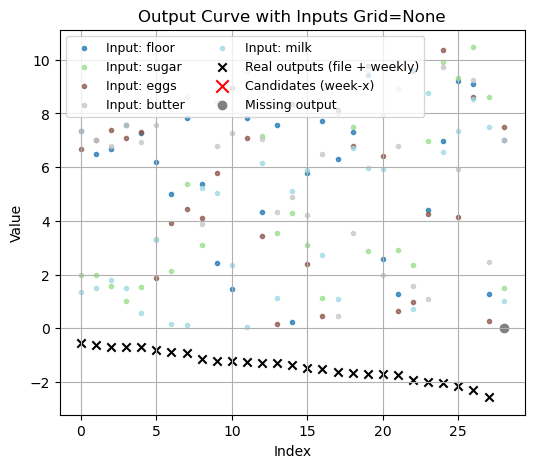

Saved LLM candidates to: results/run_2025-12-22 11-58-51/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))